# 淘宝用户行为与购买转化分析

## 1. 项目背景与分析目标

本项目基于淘宝用户行为数据，对用户从浏览商品到最终购买的行为过程进行分析。

核心分析问题：

1. 用户在平台上的主要行为分布如何？
2. 从浏览到收藏、加购和购买的转化情况如何？
3. 用户行为在不同时间段是否存在明显差异？
4. 哪些商品或商品类别具有较高的购买表现？
5. 用户的浏览、收藏和加购行为与最终购买之间存在什么关系？

分析流程：

**数据理解 → 数据清洗 → 探索性数据分析（EDA） → 转化漏斗分析 → 用户行为分析 → 业务结论**

## 2. 数据读取与数据理解

In [1]:
import pandas as pd

In [2]:
columns = [
    "user_id",
    "item_id",
    "category_id",
    "behavior_type",
    "timestamp"
]

df = pd.read_csv(
    "data/UserBehavior.csv",
    names=columns
)

### 2.1 数据读取

原始数据包含用户、商品、商品类别、行为类型和时间戳等字段。由于原始数据文件不包含列名，因此在读取数据时手动指定字段名称。

### 2.2 数据基本信息

对数据规模、字段类型、缺失值以及用户行为类型进行初步检查，为后续数据清洗和分析做准备。

In [3]:
df.head()

,user_id,item_id,category_id,behavior_type,timestamp
0,1,2268318,2520377,pv,1511544070
1,1,2333346,2520771,pv,1511561733
2,1,2576651,149192,pv,1511572885
3,1,3830808,4181361,pv,1511593493
4,1,4365585,2520377,pv,1511596146


In [4]:
df.shape

(100150807, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100150807 entries, 0 to 100150806
Data columns (total 5 columns):
 #   Column         Dtype
---  ------         -----
 0   user_id        int64
 1   item_id        int64
 2   category_id    int64
 3   behavior_type  str  
 4   timestamp      int64
dtypes: int64(4), str(1)
memory usage: 3.7 GB


In [6]:
df.isnull().sum()

user_id          0
item_id          0
category_id      0
behavior_type    0
timestamp        0
dtype: int64

In [7]:
df["behavior_type"].value_counts()

behavior_type
pv      89716264
cart     5530446
fav      2888258
buy      2015839
Name: count, dtype: int64

## 3. 数据清洗

原始数据在正式分析前需要进行数据质量检查与清洗。本部分主要对时间字段、异常时间范围以及重复记录进行处理，以保证后续分析结果的可靠性。

### 3.1 时间字段转换与异常值检查

In [8]:
pd.to_datetime(df["timestamp"].min(), unit="s"), \
pd.to_datetime(df["timestamp"].max(), unit="s")

(Timestamp('1902-05-07 22:32:46'), Timestamp('2037-04-09 05:22:35'))

In [9]:
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")

df["datetime"].describe()

count              100150807
mean     2017-11-29 10:27:56
min      1902-05-07 22:32:46
25%      2017-11-27 05:50:43
50%      2017-11-29 14:09:56
75%      2017-12-02 01:44:42
max      2037-04-09 05:22:35
Name: datetime, dtype: object

In [10]:
df["datetime"].dt.year.value_counts().sort_index()

datetime
1902            2
1905           28
1910            1
1911            1
1918           11
1919            1
1920           51
1921            1
1922           88
1929          134
1970           46
1971            1
1974            4
1975            9
1976            3
1979            9
1990            1
1991            1
1993            4
1999            5
2000            2
2001            6
2004            2
2006           11
2008           12
2009            1
2010           61
2012           42
2013           33
2014           62
2015           68
2016           81
2017    100148931
2018          296
2019          219
2020           59
2021          148
2022           19
2023            7
2024            1
2025          280
2026           11
2028            8
2030            4
2033           12
2036           29
2037            1
Name: count, dtype: int64

In [11]:
df["datetime"].dt.year.value_counts().sort_values(ascending=False).head(10)

datetime
2017    100148931
2018          296
2025          280
2019          219
2021          148
1929          134
1922           88
2016           81
2015           68
2014           62
Name: count, dtype: int64

In [12]:
(df["datetime"].dt.year == 2017).value_counts()

datetime
True     100148931
False         1876
Name: count, dtype: int64

In [13]:
df[df["datetime"].dt.year == 2017]["datetime"].dt.date.value_counts().sort_index()

datetime
2017-03-20      1
2017-04-01      1
2017-04-05      1
2017-04-11      9
2017-04-12     12
             ... 
2017-12-24      3
2017-12-26     14
2017-12-27      1
2017-12-30     32
2017-12-31    112
Name: count, Length: 140, dtype: int64

In [14]:
df["datetime"].dt.date.value_counts().head(20)

datetime
2017-12-02    13940949
2017-12-03    11961008
2017-12-01    11171515
2017-11-26    10571046
2017-11-30    10541698
2017-11-25    10511605
2017-11-29    10319066
2017-11-27    10013457
2017-11-28     9884189
2017-11-24     1220555
2017-11-23        5510
2017-11-22        1707
2017-11-21         764
2017-11-20         665
2017-11-19         631
2017-11-03         562
2017-11-02         498
2017-11-18         411
2017-10-02         354
2017-11-17         202
Name: count, dtype: int64

In [15]:
df[df["datetime"].dt.date == pd.Timestamp("2017-11-24").date()][
    "datetime"
].agg(["min", "max", "count"])

min      2017-11-24 00:00:13
max      2017-11-24 23:59:59
count                1220555
Name: datetime, dtype: object

### 3.2 分析时间范围筛选

时间字段检查发现，数据中存在少量明显偏离主要数据时间范围的异常记录。结合数据主体的时间分布，本项目选取 **2017-11-25 至 2017-12-03** 作为分析区间，并剔除该范围之外的记录。

In [40]:
df_clean = df[
    (df["datetime"] >= "2017-11-25") &
    (df["datetime"] < "2017-12-04")
].copy()

df_clean.shape

datetime
2017-03-20      1
2017-04-01      1
2017-04-05      1
2017-04-11      9
2017-04-12     12
             ... 
2017-12-24      3
2017-12-26     14
2017-12-27      1
2017-12-30     32
2017-12-31    112
Name: count, Length: 140, dtype: int64

In [17]:
df_clean["datetime"].agg(["min", "max"])

min   2017-11-25 00:00:00
max   2017-12-03 23:52:41
Name: datetime, dtype: datetime64[s]

### 3.3 重复数据检查与处理

In [18]:
df_clean.duplicated(
    subset=[
        "user_id",
        "item_id",
        "category_id",
        "behavior_type",
        "timestamp"
    ]
).sum()

np.int64(49)

In [19]:
df_clean = df_clean.drop_duplicates(
    subset=[
        "user_id",
        "item_id",
        "category_id",
        "behavior_type",
        "timestamp"
    ]
)

df_clean.shape

(98914484, 6)

对用户、商品、类别、行为类型和时间戳完全一致的记录进行重复检查。共发现 49 条完全重复记录，因此在后续分析前进行去重处理。

## 4. 用户行为总体分析

本部分从行为次数、用户覆盖规模以及时间变化趋势等角度，对用户的浏览（pv）、收藏（fav）、加购（cart）和购买（buy）行为进行分析，以了解平台用户的整体行为特征。

In [20]:
df_clean["behavior_type"].value_counts()

behavior_type
pv      88596886
cart     5466118
fav      2852536
buy      1998944
Name: count, dtype: int64

### 4.1 各类用户行为数量与占比

In [21]:
behavior_count = df_clean["behavior_type"].value_counts()

behavior_pct = behavior_count / behavior_count.sum() * 100

behavior_pct

behavior_type
pv      89.569174
cart     5.526105
fav      2.883841
buy      2.020881
Name: count, dtype: float64

#### 分析结论

用户行为以浏览（PV）为主，占全部行为的约 **89.57%**；加购、收藏和购买行为占比分别约为 **5.53%、2.88% 和 2.02%**。

整体呈现出明显的“高浏览、低购买”特征，说明用户在商品浏览之后存在较明显的行为流失。

### 4.2 各类行为覆盖用户数

In [22]:
user_behavior = df_clean.groupby("behavior_type")["user_id"].nunique()

user_behavior

behavior_type
buy     670370
cart    737393
fav     388261
pv      984080
Name: user_id, dtype: int64

In [23]:
buy_user_rate = user_behavior["buy"] / user_behavior["pv"] * 100

buy_user_rate

np.float64(68.12149418746444)

In [24]:
df_clean["date"] = df_clean["datetime"].dt.date

In [25]:
daily_behavior = (
    df_clean
    .groupby(["date", "behavior_type"])
    .size()
    .unstack(fill_value=0)
)

daily_behavior

behavior_type,buy,cart,fav,pv
date,,,,
2017-11-25,201297,569236,305814,9435250
2017-11-26,214308,575420,305722,9475589
2017-11-27,218401,539212,289413,8966429
2017-11-28,211754,533807,289431,8849193
2017-11-29,223077,554747,299588,9241648
2017-11-30,222235,573032,304428,9442000
2017-12-01,212849,642251,314121,10002284
2017-12-02,259550,801367,404821,12475204
2017-12-03,235473,677046,339198,10709289


### 4.3 每日用户行为趋势

为了观察用户活跃度随日期的变化，将四类用户行为按日期进行汇总，并比较不同日期的行为数量变化。

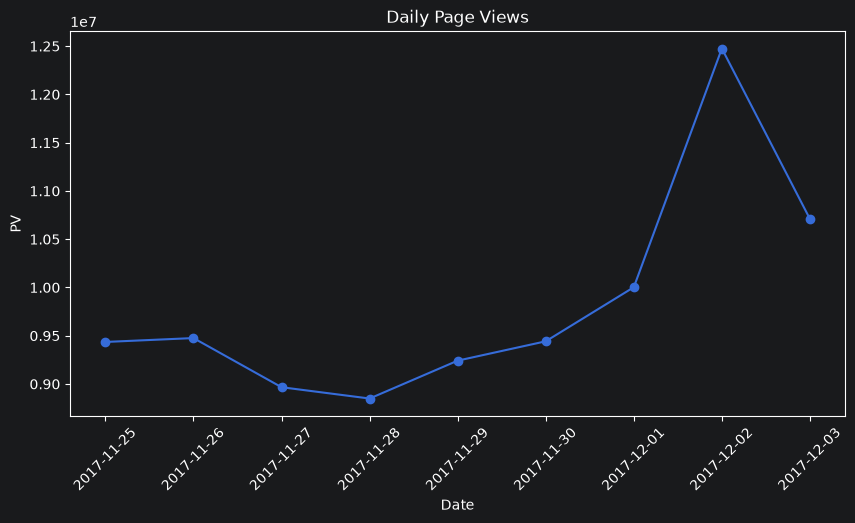

In [26]:
import matplotlib.pyplot as plt

daily_behavior["pv"].plot(figsize=(10, 5), marker="o")

plt.title("Daily Page Views")
plt.xlabel("Date")
plt.ylabel("PV")
plt.xticks(rotation=45)
plt.show()

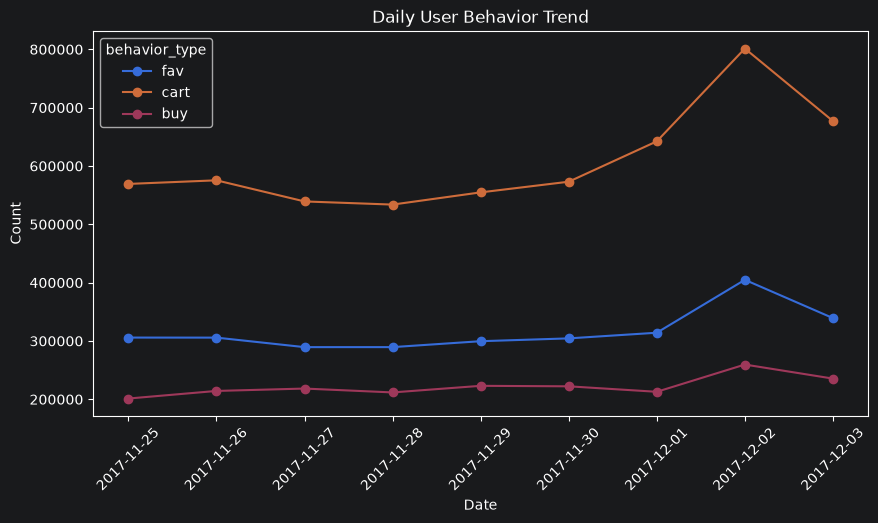

In [27]:
daily_behavior[["fav", "cart", "buy"]].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Daily User Behavior Trend")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### 分析结论

各类用户行为整体呈现较为一致的时间变化趋势。12月2日平台浏览、收藏、加购和购买行为均出现明显增长，其中浏览量达到分析期内最高水平。

这表明该日期平台整体用户活跃度显著提升，可能存在促销活动或其他外部因素影响。由于当前数据未提供活动信息，因此无法进一步确认具体原因。

### 4.4 每日行为率分析

为排除每日浏览规模变化带来的影响，进一步计算收藏、加购和购买行为次数相对于浏览次数的比例，观察不同日期用户行为结构的变化。

In [28]:
daily_behavior["cart_rate"] = (
    daily_behavior["cart"] / daily_behavior["pv"] * 100
)

daily_behavior["fav_rate"] = (
    daily_behavior["fav"] / daily_behavior["pv"] * 100
)

daily_behavior["buy_rate"] = (
    daily_behavior["buy"] / daily_behavior["pv"] * 100
)

daily_behavior[["cart_rate", "fav_rate", "buy_rate"]]

behavior_type,cart_rate,fav_rate,buy_rate
date,,,
2017-11-25,6.033078,3.241186,2.133457
2017-11-26,6.072657,3.226417,2.261685
2017-11-27,6.013676,3.227740,2.435763
2017-11-28,6.032268,3.270705,2.392919
2017-11-29,6.002685,3.241716,2.413823
2017-11-30,6.068968,3.224190,2.353686
2017-12-01,6.421043,3.140493,2.128004
2017-12-02,6.423679,3.245005,2.080527
2017-12-03,6.322044,3.167325,2.198773


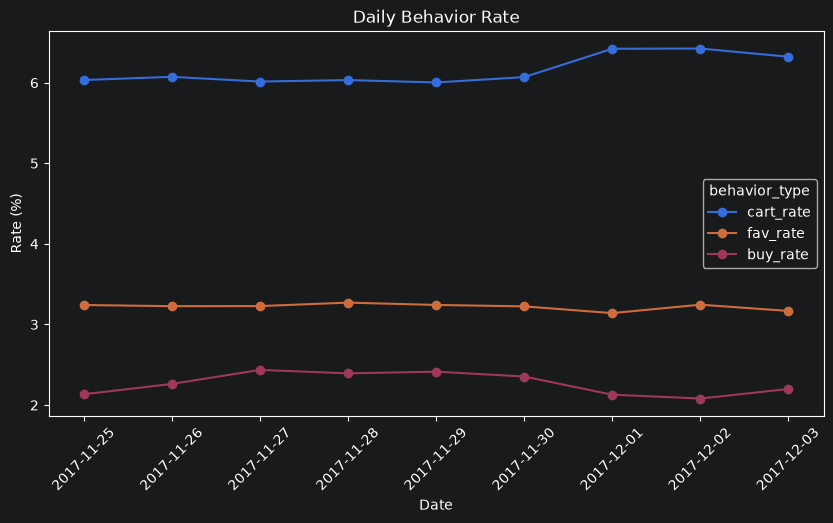

In [29]:
daily_behavior[["cart_rate", "fav_rate", "buy_rate"]].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Daily Behavior Rate")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.xticks(rotation=45)
plt.show()

#### 分析结论

分析期内，加购率整体维持在约 **6%–6.4%**，收藏率约为 **3.1%–3.3%**，购买率约为 **2.1%–2.4%**，整体波动较小。

虽然12月2日各类行为数量明显增长，但行为率并未同步大幅提高，说明该日增长更多体现为整体用户活跃规模的提升，而非购买倾向发生明显变化。

In [30]:
user_action = (
    df_clean
    .groupby(["user_id", "behavior_type"])
    .size()
    .unstack(fill_value=0)
)

user_action.head()

behavior_type,buy,cart,fav,pv
user_id,,,,
1,0,0,0,53
2,7,3,7,54
3,0,15,5,33
4,4,13,0,268
5,0,0,0,64


#### 5. 购买用户特征分析

在总体行为分析的基础上，本部分进一步从用户维度区分购买用户与未购买用户，并比较两类用户的浏览、收藏和加购行为特征，以探索不同用户行为与最终购买之间的关系。

In [31]:
buyer_count = (user_action["buy"] > 0).sum()
non_buyer_count = (user_action["buy"] == 0).sum()

buyer_count, non_buyer_count

(np.int64(670370), np.int64(317614))

In [32]:
buyer_rate = buyer_count / (buyer_count + non_buyer_count) * 100

buyer_rate

np.float64(67.85231339778782)

#### 分析结论

分析期内约 **67.85%** 的活跃用户至少产生过一次购买行为，说明多数活跃用户在观察期内存在实际购买行为。

需要注意，该指标为用户维度的购买用户占比，与前文基于行为次数计算的购买行为占比并不相同。

### 5.2 购买用户与未购买用户行为对比

In [33]:
user_action["is_buyer"] = user_action["buy"] > 0

user_action.head()

behavior_type,buy,cart,fav,pv,is_buyer
user_id,,,,,
1,0,0,0,53,False
2,7,3,7,54,True
3,0,15,5,33,False
4,4,13,0,268,True
5,0,0,0,64,False


In [34]:
buyer_compare = user_action.groupby("is_buyer")[["pv", "cart", "fav"]].mean()

buyer_compare

behavior_type,pv,cart,fav
is_buyer,,,
False,71.627431,3.873016,2.471236
True,98.224877,6.318890,3.084322


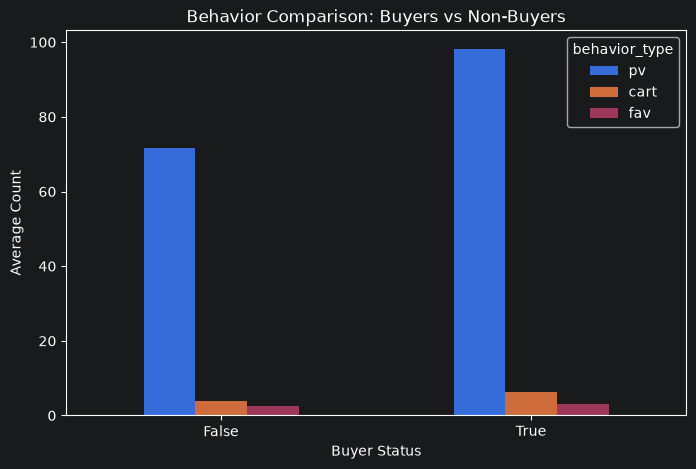

In [35]:
buyer_compare.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Behavior Comparison: Buyers vs Non-Buyers")
plt.xlabel("Buyer Status")
plt.ylabel("Average Count")
plt.xticks(rotation=0)
plt.show()

In [36]:
behavior_diff = (
    (buyer_compare.loc[True] - buyer_compare.loc[False])
    / buyer_compare.loc[False]
    * 100
)

behavior_diff

behavior_type
pv      37.133044
cart    63.151665
fav     24.808909
dtype: float64

#### 分析结论

购买用户整体表现出更高的活跃度。与未购买用户相比：

- 人均浏览次数高约 **37.13%**
- 人均加购次数高约 **63.15%**
- 人均收藏次数高约 **24.81%**

其中，加购行为的差异最为明显，表明加购行为与最终购买之间存在较强关联。

从业务角度看，可重点关注已经产生加购行为但尚未完成购买的用户，通过购物车提醒、优惠激励等方式促进进一步转化。

## 6. 用户购买转化漏斗分析

为了从用户维度观察购买转化过程，将用户行为划分为三个阶段：

1. **浏览用户（PV Users）**：至少产生过一次浏览行为的用户
2. **意向用户（Intent Users）**：至少产生过收藏或加购行为的用户
3. **购买用户（Buy Users）**：至少产生过一次购买行为的用户

由于收藏和加购行为不存在严格的先后顺序，因此将两者合并定义为购买意向阶段。

In [37]:
pv_users = (user_action["pv"] > 0).sum()

intent_users = (
    (user_action["cart"] > 0) |
    (user_action["fav"] > 0)
).sum()

buy_users = (user_action["buy"] > 0).sum()

pv_users, intent_users, buy_users

(np.int64(984080), np.int64(857858), np.int64(670370))

In [38]:
pv_to_intent = intent_users / pv_users * 100
intent_to_buy = buy_users / intent_users * 100
pv_to_buy = buy_users / pv_users * 100

print("浏览 → 意向转化率:", round(pv_to_intent, 2), "%")
print("意向 → 购买转化率:", round(intent_to_buy, 2), "%")
print("浏览 → 购买转化率:", round(pv_to_buy, 2), "%")

浏览 → 意向转化率: 87.17 %
意向 → 购买转化率: 78.14 %
浏览 → 购买转化率: 68.12 %


### 6.1 漏斗转化结果

用户转化漏斗结果如下：

- 浏览用户：**984,080**
- 意向用户：**857,858**
- 购买用户：**670,370**

对应转化率：

- 浏览 → 意向：**87.17%**
- 意向 → 购买：**78.14%**
- 浏览 → 购买：**68.12%**

整体来看，大部分浏览用户会进一步产生收藏或加购行为，同时产生购买意向的用户中有较高比例最终完成购买。

相比浏览到意向阶段，意向到购买阶段仍存在一定用户流失，因此已经收藏或加购但尚未购买的用户，是值得重点关注的潜在转化群体。

### 6.2 转化漏斗可视化

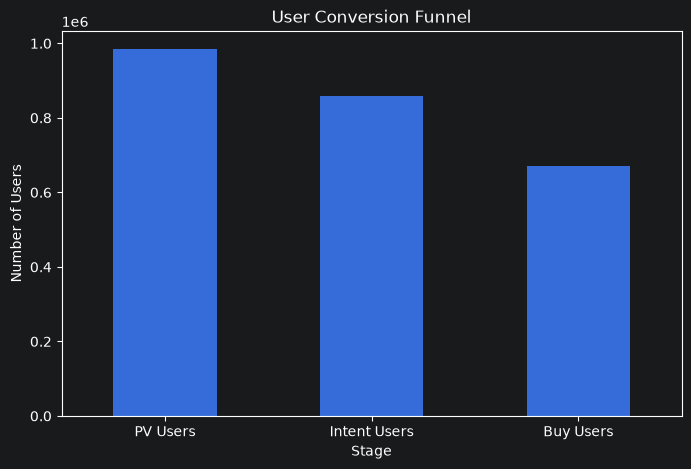

In [39]:
funnel = pd.Series({
    "PV Users": pv_users,
    "Intent Users": intent_users,
    "Buy Users": buy_users
})

funnel.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("User Conversion Funnel")
plt.xlabel("Stage")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.show()

#### 分析结论

从用户转化路径来看，984,080 名浏览用户中有 857,858 名用户产生收藏或加购行为，浏览到意向阶段的转化率为 87.17%；其中 670,370 名用户最终完成购买，意向到购买的转化率为 78.14%。

整体浏览到购买的用户转化率达到 68.12%，说明产生浏览行为的用户中有较高比例最终完成购买。同时，意向用户与购买用户之间仍存在一定流失，后续可进一步结合收藏、加购等行为特征分析用户购买转化差异。

## 7. 总结与业务建议

本项目基于淘宝用户行为数据，从用户行为分布、时间趋势、购买用户特征以及用户转化路径等角度进行了分析，以了解用户在浏览、收藏、加购和购买过程中的行为特征，并探索影响购买转化的潜在因素。

### 7.1 主要分析结论

1. **用户行为以浏览为主。**
   浏览（PV）行为约占全部行为的 89.6%，加购、收藏和购买行为占比较低，符合典型电商用户从浏览到购买逐步转化的行为特征。

2. **用户活跃度存在明显的时间波动。**
   分析期间各类用户行为整体变化趋势较为一致，其中 12 月 2 日浏览、收藏、加购和购买行为均出现明显增长，平台整体活跃度达到阶段性高点。

3. **购买用户表现出更高的活跃程度。**
   与未购买用户相比，购买用户平均浏览、加购和收藏次数均更高，其中加购行为差异尤其明显，说明较高的用户互动程度与最终购买行为存在较强关联。

4. **用户整体转化路径较为顺畅。**
   浏览用户中约 87.17% 产生收藏或加购等意向行为，意向用户中约 78.14% 最终产生购买行为，浏览用户到购买用户的整体转化率约为 68.12%。

### 7.2 业务建议

基于上述分析，可以重点关注用户的收藏和加购行为，将其作为识别潜在购买用户的重要信号。针对已经产生加购或收藏行为但尚未购买的用户，可以通过商品提醒、优惠活动等方式促进进一步转化。

同时，可以重点分析高活跃日期的用户行为变化，并结合实际促销活动、节假日等外部信息判断流量增长原因，从而为后续营销活动和运营策略提供参考。

此外，购买用户整体表现出更高的浏览和互动频率，因此可以进一步基于用户历史行为构建用户分层或购买倾向模型，对高潜力用户进行更精准的运营。